In [38]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np,random
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.svm import LinearSVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense,Dropout


In [39]:
path_of_dir=os.listdir('../brain tumor/')
classes_in_dir={'Brain Tumor':1,'Healthy':0}

classes_in_dir

{'Brain Tumor': 1, 'Healthy': 0}

def safe_augment1(img):
    h, w = img.shape[:2]
    # 1. Fixed rotation (e.g., 5 degrees)
    angle = 5
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)
    # 2. Fixed zoom (e.g., 1.05x)
    zf = 1.05
    zh, zw = int(h*zf), int(w*zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h)//2, 0)
    start_x = max((zw - w)//2, 0)
    img = img[start_y:start_y+h, start_x:start_x+w]
    # 3. Fixed brightness (+10)
    beta = 10
    img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)
    # 4. Fixed gamma (1.05)
    gamma = 1.05
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)
    # 5. Always apply Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3), 0)
    # 6. Always flip horizontally
    img = cv2.flip(img, 1)
    return img






In [108]:
def safe_mri_augment1(img):
    h, w = img.shape[:2]

    # 1. Fixed rotation (+3°)
    angle = 3
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Fixed zoom (1.02x)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Fixed gamma correction
    gamma = 1.02
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 4. Deterministic constant noise (+1 pixel everywhere)
    fixed_noise = np.full(img.shape, 1, dtype=np.int16)
    img = np.clip(img.astype(np.int16) + fixed_noise, 0, 255).astype(np.uint8)

    return img



def safe_mri_augment2(img):
    # Mild brightness change (+0.05)
    img = np.clip(img + 0.05, 0, 1.0)
    
    # Mild contrast scaling (×1.05)
    img = np.clip(img * 1.05, 0, 1.0)
    
    # Optional: Gaussian blur to reduce noise
    img = cv2.GaussianBlur(img, (3, 3), 0)
    
    return img


def safe_mri_augment3(img):
    h, w = img.shape[:2]

    # 1. Small fixed rotation (3°)
    angle = 3
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Very small zoom (1.02x)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h) // 2, 0)
    start_x = max((zw - w) // 2, 0)
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Mild brightness adjustment (+5)
    beta = 5
    img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)

    # 4. Slight gamma correction (1.02)
    gamma = 1.02
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 5. Gentle Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # 6. Always horizontal flip
    img = cv2.flip(img, 1)

    return img

def safe_mri_augment4(img):
    h, w = img.shape[:2]

    # 1. Small rotation (±3°)
    angle = 3
    M_rot = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Slight zoom (1.02x)
    zf = 1.02
    zh, zw = int(h * zf), int(w * zf)
    img = cv2.resize(img, (zw, zh))
    start_y = (zh - h) // 2
    start_x = (zw - w) // 2
    img = img[start_y:start_y + h, start_x:start_x + w]

    # 3. Mild contrast adjustment
    gamma = 1.02
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    return img




 
def safe_mri_augment5(img):
    # Mild brightness increase
    img = np.clip(img + 0.05, 0, 1.0)
    
    # Mild contrast
    img = np.clip(img * 1.05, 0, 1.0)
    
    # Gaussian blur
    img = cv2.GaussianBlur(img, (3,3), 0)
    
    return img
 

In [137]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --------------------
# Load dataset
# --------------------
path_of_dir = os.listdir('../brain tumor/')
classes_in_dir = {'Brain Tumor': 1, 'Healthy': 0}

X, Y = [], []
for cls in classes_in_dir:
    path = '../brain tumor/' + cls
    for file in os.listdir(path):
        img = cv2.imread(os.path.join(path, file), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (200, 200))
        X.append(img)
        Y.append(classes_in_dir[cls])

x = np.array(X, dtype="float32")
y = np.array(Y)

# Split train/test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=True, random_state=42
)

# --------------------
# Augmentations (make sure these functions exist)
# --------------------
x_train_aug1 = np.array([safe_mri_augment1(img) for img in x_train], dtype="float32")
x_train_aug2 = np.array([safe_mri_augment2(img) for img in x_train], dtype="float32")
x_train_aug3 = np.array([safe_mri_augment3(img) for img in x_train], dtype="float32")
x_train_aug4 = np.array([safe_mri_augment4(img) for img in x_train], dtype="float32")
x_train_aug5 = np.array([safe_mri_augment5(img) for img in x_train], dtype="float32")

# --------------------
# Combine original + selected augmentation for each model
# --------------------
def combine_with_labels(x_orig, y_orig, x_aug):
    x_comb = np.concatenate([x_orig, x_aug], axis=0)
    y_comb = np.concatenate([y_orig, y_orig[:len(x_aug)]], axis=0)
    return x_comb, y_comb

x_train_cnn, y_train_cnn = combine_with_labels(x_train, y_train, x_train_aug1)  # CNN
x_train_rf,  y_train_rf  = combine_with_labels(x_train, y_train, x_train_aug2)  # RF
x_train_svm, y_train_svm = combine_with_labels(x_train, y_train, x_train_aug3)  # SVM
x_train_knn, y_train_knn = combine_with_labels(x_train, y_train, x_train_aug4)  # KNN
x_train_lr,  y_train_lr  = combine_with_labels(x_train, y_train, x_train_aug5)  # LR

# --------------------
# Normalize / reshape
# --------------------
# CNN: keep 4D
x_train_cnn = x_train_cnn.reshape(-1, 200, 200, 1) / 255.0
x_test_cnn  = x_test.reshape(-1, 200, 200, 1) / 255.0

# ML models: flatten 2D
x_train_rf  = x_train_rf.reshape(len(x_train_rf), -1) / 255.0
x_train_svm = x_train_svm.reshape(len(x_train_svm), -1) / 255.0
x_train_knn = x_train_knn.reshape(len(x_train_knn), -1) / 255.0
x_train_lr  = x_train_lr.reshape(len(x_train_lr), -1) / 255.0
x_test_ml   = x_test.reshape(len(x_test), -1) / 255.0

# --------------------
# StandardScaler for ML models
# --------------------
scaler = StandardScaler()
x_train_rf  = scaler.fit_transform(x_train_rf)
x_train_svm = scaler.fit_transform(x_train_svm)
x_train_knn = scaler.fit_transform(x_train_knn)
x_train_lr  = scaler.fit_transform(x_train_lr)
x_test_ml   = scaler.transform(x_test_ml)

# --------------------
# Labels
# --------------------
y_train_cnn = np.array(y_train_cnn)
y_train_rf  = np.array(y_train_rf)
y_train_svm = np.array(y_train_svm)
y_train_knn = np.array(y_train_knn)
y_train_lr  = np.array(y_train_lr)
y_test      = np.array(y_test)

# --------------------
# Check shapes
# --------------------
print("CNN Train:", x_train_cnn.shape, y_train_cnn.shape)
print("RF Train :", x_train_rf.shape, y_train_rf.shape)
print("SVM Train:", x_train_svm.shape, y_train_svm.shape)
print("KNN Train:", x_train_knn.shape, y_train_knn.shape)
print("LR Train :", x_train_lr.shape, y_train_lr.shape)
print("CNN Test :", x_test_cnn.shape, y_test.shape)
print("ML Test  :", x_test_ml.shape, y_test.shape)


CNN Train: (6400, 200, 200, 1) (6400,)
RF Train : (6400, 40000) (6400,)
SVM Train: (6400, 40000) (6400,)
KNN Train: (6400, 40000) (6400,)
LR Train : (6400, 40000) (6400,)
CNN Test : (800, 200, 200, 1) (800,)
ML Test  : (800, 40000) (800,)


In [43]:
#plt.imshow(x_test3D[5])
#plt.xlabel(y_test3D[5])


#CNN MODEL

In [44]:
cnn=Sequential([keras.layers.Input(shape=(200,200,1)),
Conv2D(filters=32, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1, activation='sigmoid')

])

cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 198, 198, 32)      320       
                                                                 
 batch_normalization_2 (Batc  (None, 198, 198, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 99, 99, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 batch_normalization_3 (Batc  (None, 97, 97, 64)       256       
 hNormalization)                                                 
                                                      

In [45]:
cnn.compile(optimizer=Adam(learning_rate=1e-4),loss='binary_crossentropy', metrics=['accuracy'])

In [46]:
cnn.fit(x_train3D1,y_train3D1,validation_data=(x_test3D,y_test3D), epochs=3, batch_size=16)

Epoch 1/3
400/400 [==============================] - 115s 284ms/step - loss: 0.3767 - accuracy: 0.8737 - val_loss: 0.3713 - val_accuracy: 0.8175
Epoch 2/3
400/400 [==============================] - 113s 283ms/step - loss: 0.0898 - accuracy: 0.9670 - val_loss: 0.1234 - val_accuracy: 0.9513
Epoch 3/3
400/400 [==============================] - 114s 284ms/step - loss: 0.0308 - accuracy: 0.9905 - val_loss: 0.1446 - val_accuracy: 0.9538


In [47]:
test_loss,test_acc=cnn.evaluate(x_test3D,y_test3D,verbose=2)

25/25 - 4s - loss: 0.1446 - accuracy: 0.9538 - 4s/epoch - 155ms/step


In [48]:
pred1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()

25/25 [==============================] - 4s 142ms/step


In [49]:
print(pred1[0:20])

[1 0 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1]


In [50]:
accuracy_score(y_test3D,pred1)

0.95375

In [51]:
conf_mat= confusion_matrix(y_test3D,pred1)
print(classification_report(y_test3D,pred1))


              precision    recall  f1-score   support

           0       0.95      0.96      0.95       378
           1       0.96      0.95      0.96       422

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



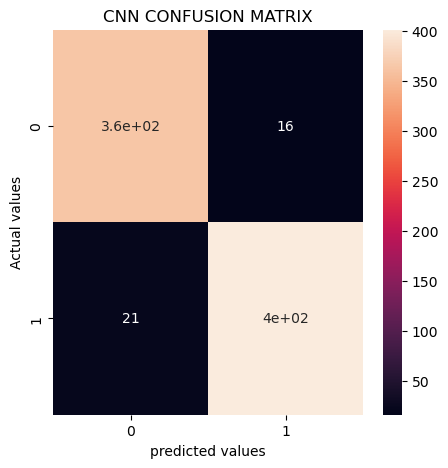

In [52]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [138]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,       # reduce depth
    min_samples_split=5, 
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)


rf.fit(x_train_rf, y_train_rf)



RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [140]:
pred2=rf.predict(x_test_ml)

In [141]:
print("train= ",rf.score(x_train_rf,y_train_rf))
print("validation= ",accuracy_score(y_test,pred2))

train=  0.95703125
validation=  0.96


In [ ]:

conf_mat2=confusion_matrix(y_test,pred2)


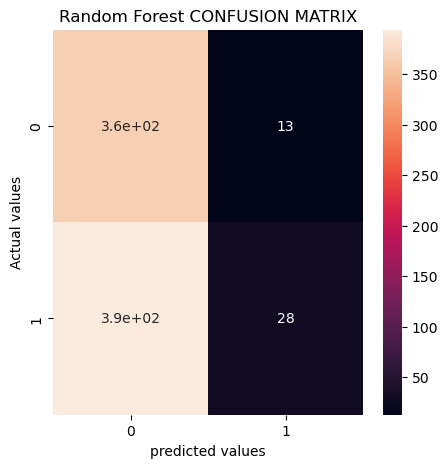

In [142]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [143]:

# ----------------------
# SVM Pipeline
# ----------------------
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),          # standardize features
    ('pca', PCA(n_components=500)),        # reduce dimensionality
    ('svm', SVC(kernel='rbf', C=5.0, gamma='scale'))  # RBF kernel
])

# Fit the model
svm_pipeline.fit(x_train_svm, y_train_svm)

# Predictions
pred_train = svm_pipeline.predict(x_train_svm)
pred3 = svm_pipeline.predict(x_test_ml)

# Accuracy
train_acc = svm_pipeline.score(x_train_svm, y_train_svm)
val_acc   = svm_pipeline.score(x_test_ml, y_test)

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)


Train Accuracy: 0.9971875
Validation Accuracy: 0.76625


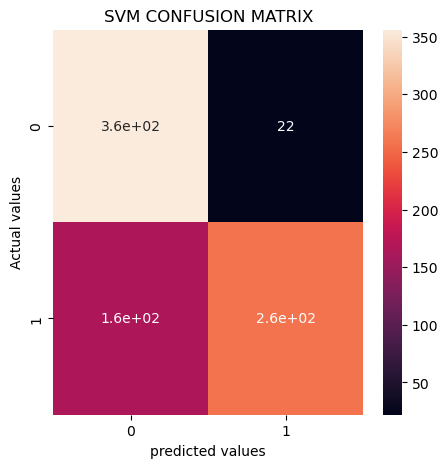

In [144]:
conf_mat3=confusion_matrix(y_test2D,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [145]:
knn =KNeighborsClassifier(n_neighbors=3, weights='distance',metric= 'manhattan')
knn.fit(x_train_knn, y_train_knn) 

KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

In [146]:
pred4=knn.predict(x_test_ml)

In [147]:
print("Accuracy:", accuracy_score(y_test, pred4))

Accuracy: 0.71625


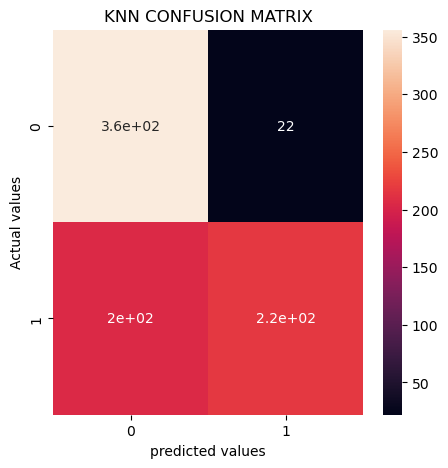

In [149]:
conf_mat4=confusion_matrix(y_test,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [150]:
LR = LogisticRegression(
    C=0.0054,
    class_weight="balanced",
    penalty='l2',
    solver='liblinear',
    max_iter=100
)
LR.fit(x_train_lr, y_train_lr)

LogisticRegression(C=0.0054, class_weight='balanced', solver='liblinear')

In [151]:
print("Train:", LR.score(x_train_lr, y_train_lr))
print("Validation:", LR.score(x_test_ml, y_test))

Train: 0.84671875
Validation: 0.94


In [ ]:
pred5 = LR.predict(x_test_ml)

print("Accuracy:", accuracy_score(y_test, pred5))
print("\nClassification Report:\n", classification_report(y_test, pred5))

Accuracy: 0.5425

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.03      0.06       378
           1       0.54      1.00      0.70       422

    accuracy                           0.54       800
   macro avg       0.77      0.52      0.38       800
weighted avg       0.75      0.54      0.40       800



Accuracy: 0.9275

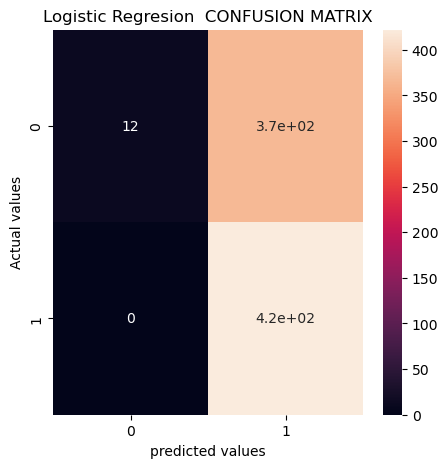

In [152]:
conf_mat5= confusion_matrix(y_test,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

# ALL PREDICTED VALUES

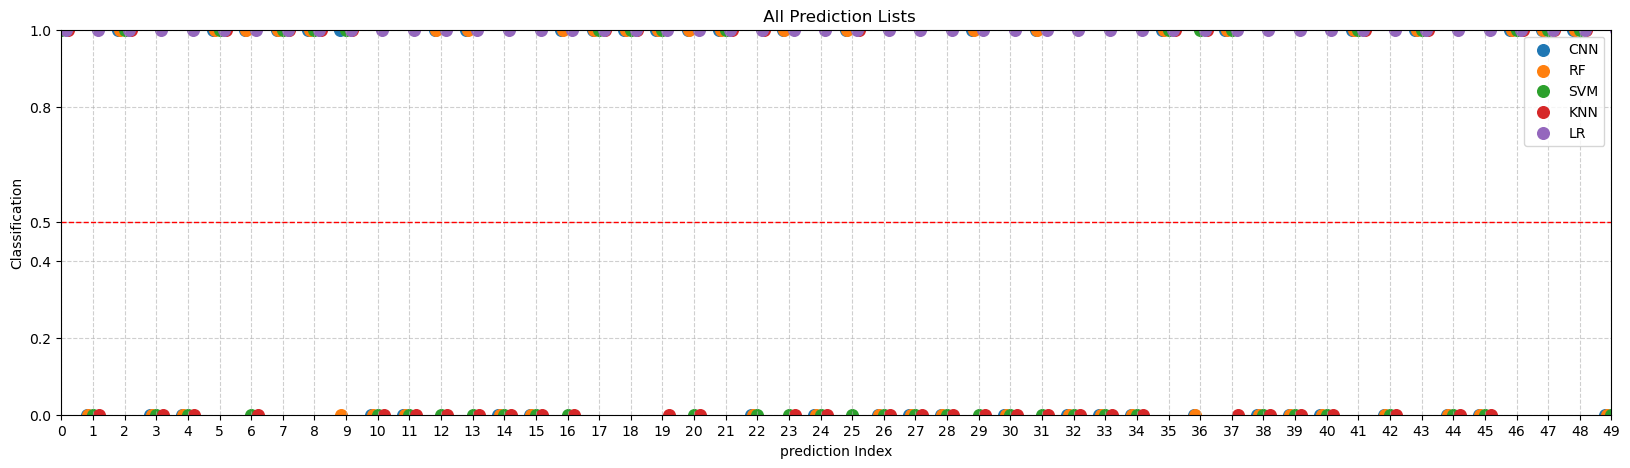

In [153]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [154]:
pp1=(cnn.predict(x_test_cnn)>0.5).astype('int').flatten()
pp2=rf.predict(x_test_ml)
pp3=svm_pipeline.predict(x_test_ml)
pp4=knn.predict(x_test_ml)
pp5=LR.predict(x_test_ml)

25/25 [==============================] - 5s 153ms/step


In [155]:
print(pp1[0:2])

[1 0]


In [156]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [157]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[1, 0, 1, 0, 0, 1]


In [158]:
print(y_test[0:6])

[1 0 1 0 0 1]


In [159]:
print(pred1[0:6])

[1 0 1 0 0 1]


In [160]:
print(pred2[0:6])

[1 0 1 0 0 1]


In [161]:
print(pred3[0:6])

[1 0 1 0 0 1]


In [162]:
print(pred4[0:6])

[1 0 1 0 0 1]


In [164]:
print(pred5[0:6])

[1 1 1 1 1 1]


In [165]:
g=np.where(y_test2D != Ensemble_prediction)[0]
print(g)

[ 53  57  72  92 110 111 154 179 183 220 255 282 298 302 362 398 460 484
 492 509 530 635 638 698 719]


In [166]:
print("Accuracy:", accuracy_score(y_test2D, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test2D, Ensemble_prediction))

Accuracy: 0.96875

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       378
           1       0.97      0.97      0.97       422

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



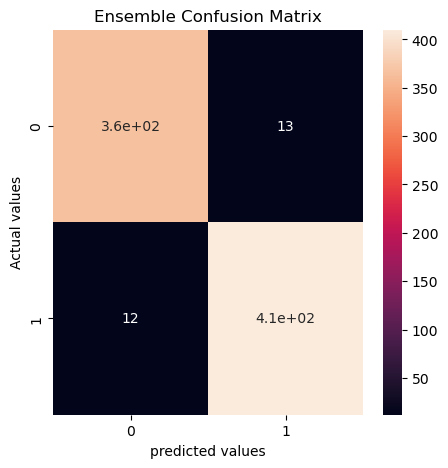

In [167]:
ensemble_confusion_matrix= confusion_matrix(y_test2D,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

In [168]:
x_pred, y_pred = [], []
img_path = r"D:\My Final Work\external_pic" 
for j in os.listdir(img_path):
        pic = cv2.imread(img_path + '/' + j, 0)  
        pic = cv2.resize(pic, (200, 200))                       
        pic = np.array(pic)
        x_pred.append(pic)
        y_pred.append(j)


(-0.5, 199.5, 199.5, -0.5)

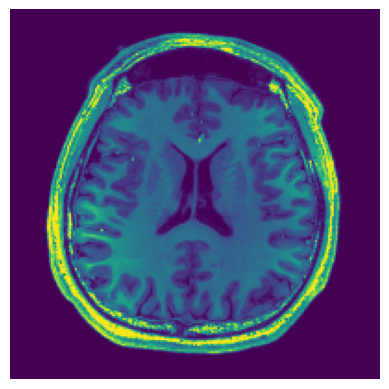

In [169]:
plt.imshow(x_pred[1])
plt.axis('off')

In [170]:
img_path = r"D:\My Final Work\external_pic"
images_cnn = []   
images_flat = []  
filenames = []

for file in os.listdir(img_path):
    path = os.path.join(img_path, file)
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (200, 200))
    images_cnn.append(img)
    images_flat.append(img.reshape(-1))
    filenames.append(file)
images_cnn = np.array(images_cnn).reshape(-1, 200, 200, 1) / 255.0
images_flat =np.array(images_flat)/255
pred_cnn = (cnn.predict(images_cnn) > 0.5).astype(int).flatten()
pred_rf  = rf.predict(images_flat)
pred_svm = svm_pipeline.predict(images_flat)
pred_lr  = LR.predict(images_flat)
pred_knn = knn.predict(images_flat)
results = []
for i, name in enumerate(filenames):
    votes = pred_cnn[i] + pred_rf[i] + pred_svm[i] + pred_lr[i] + pred_knn[i]
    if votes >= 3:
        label = "Tumor"
    else:
        label = "No Tumor"

    results.append((name, label))
print("\n Total Predictions:")
for file, label in results:
   print(file + " -------> " + label)



1/1 [==============================] - 0s 216ms/step

 Total Predictions:
h1.jpeg -------> No Tumor
h2.jpg -------> No Tumor
h3.jpeg -------> No Tumor
h4.jpeg -------> Tumor
h5.jpeg -------> No Tumor
h6.jpg -------> No Tumor
t1.jpeg -------> No Tumor
t4.jpeg -------> No Tumor
t5.png -------> No Tumor
t6.jpeg -------> Tumor


In [171]:
img_path2 = r"D:\My Final Work\external_pic/t1.jpeg" 
pic1 = cv2.imread(img_path2,0)  
pic1= cv2.resize(pic1, (200, 200))


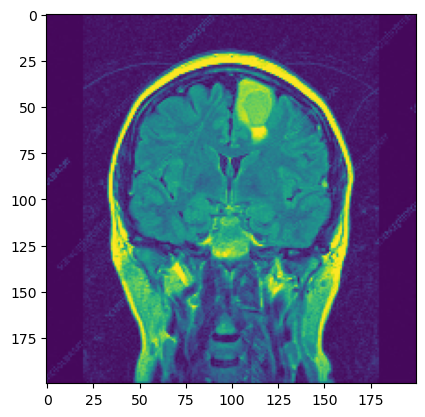

In [172]:
plt.imshow(pic1)

In [173]:
cnnpred1 = pic1.reshape(1, 200, 200, 1)
cnnpred = cnnpred1 / 255.0

In [174]:
cnnpred.shape

(1, 200, 200, 1)

In [175]:
p11 = (cnn.predict(cnnpred) > 0.5).astype('int').flatten()

1/1 [==============================] - 0s 65ms/step


In [176]:
print(p11)

[0]


In [177]:
p_2D=cnnpred.reshape(1, -1)
p_2D.shape

(1, 40000)

In [178]:
x_scaled = p_2D/255
p22=rf.predict(x_scaled)
p33=svm_pipeline.predict(x_scaled)
p44=LR.predict(x_scaled)
p55 = knn.predict(x_scaled)
print('CNN =',p11)
print('RF =',p22)
print('SVM =',p33)
print('LR =',p44)
print('KNN =',p55)

if(p11+p22+p33+p44+p55 >= 3):
    print(" \n Tumor")
elif (p11+p22+p33+p44+p55 < 3):
    print( "\n No Tumor")

CNN = [0]
RF = [0]
SVM = [0]
LR = [0]
KNN = [0]

 No Tumor
